Implement the simulation described above using a 1024 x 1024 lattice using at least 10^6 Monte Carlo steps.

To generate the initial ice sheet, randomly assign heights, but then fix these heights for all simulations. You can do so by manually setting a seed for the random number generator inside the random module in Python.
Then, randomly assign each site to be either ice (-1) or water (+1) such that the fraction of water squares Fin (or, equivalently, the probability of a square being a water square) is fixed. Fin is an input parameter in your simulation.

Implement the algorithm outlined in the “Background” section for Fin = 0.34, 0.42, and 0.48 (note: make sure to implement periodic boundary conditions!). Discard the first 10^5 simulation steps, because the system is not yet at equilibrium. For the remaining steps, calculate the average Fout, the fraction of the lattice covered by water molecules at all of the other points in the simulation. Since we are assuming all of these steps are in a dynamic equilibrium, this is the final water coverage once things have equilibrated.

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib import cm
import numpy as np

In [ ]:
###Helper functions

##Initialize height array with helper function mapping_height
np.random.seed(5)
def mapping_height(n):
  """Given an int n, map an numpy array of nxn with assigned random heights (-1,1) Return mapped lattice
  parameters: n(int)"""
  lattice_height = np.ones((n,n))
  for j in range(n):
    for i in range(n):
      lattice_height[j,i] = lattice_height[j,i]*(2*np.random.random()-1)

  return lattice_height

##Initialize water_ice_lattice with helper function mapping_ice
def mapping_ice(Fin,n):
  """given the percentege (in decimal form) of the water in the lattice, randomly map the corresponding number of elements in array to be ice.
  given an int n, initiate all water array (all 1.0)
  return an array with ice and water mapped.
  parameters: Fin (float); n (int)"""

  lattice_ice_water = np.ones((n,n)) #intiate array as all water

  total_ice = (1-Fin)*n**2 #Fin is the water fraction, total_ice = total number of ice

  while total_ice > 1: #Mapping certain percentage into ice
    i = np.random.randint(n) #random i
    j = np.random.randint(n) #random j
    if np.random.randint(2) == 0 and lattice_ice_water[j,i] == 1.0 and total_ice > 1: #turn into ice (1.0 -> -1.0)
      lattice_ice_water[j,i] = -1.0
      total_ice -= 1

  return lattice_ice_water #mapped lattice

##Monte Carlo single step helper function
def mc_lattice(lattice_ice_water,lattice_height):
  """Helper function that takes the lattice for ice and water and the lattice with height, return a tuple of phase_float and if it has chaged phase(ice to water or vice versa)"""
  n = len(lattice_ice_water) #number of rows
  x = np.random.randint(n) #0 to n-1
  y = np.random.randint(n) #0 to n-1
  changed = False
  phase_float = float(lattice_ice_water[x,y]) #the initial phase of the chose random lattice[y,x]

  try: # for edge cases
    left = lattice_ice_water[x-1,y]
    right = lattice_ice_water[x+1,y]
    up = lattice_ice_water[x,y-1]
    down = lattice_ice_water[x,y+1]
  except IndexError:
    if x == (n-1) and y == (n-1):
      left = lattice_ice_water[x-1,y]
      right = lattice_ice_water[0,y] #changed from n to 0
      up = lattice_ice_water[x,y-1]
      down = lattice_ice_water[x,0] #changed from n to 0
    elif y == (n-1):
      left = lattice_ice_water[x-1,y]
      right = lattice_ice_water[x+1,y]
      up = lattice_ice_water[x,y-1]
      down = lattice_ice_water[x,0] #changed from n to 0
    elif x == (n-1):
      left = lattice_ice_water[x-1,y]
      right = lattice_ice_water[0,y] #changed from n to 0
      up = lattice_ice_water[x,y-1]
      down = lattice_ice_water[x,y+1]

  surrounding_ice_water = [left,right,up,down] #list of value (1.0(water) or -1.0(ice))
  count_water = 0
  count_ice = 0

  for pos in surrounding_ice_water:
    if pos == 1.0:
      count_water += 1 #water is represented by 1.0 in the grid
    elif pos == -1.0:
      count_ice += 1 #ice is represented by -1.0 in the grid

  if count_water == count_ice:
    if lattice_height[x,y] < 0:
      lattice_ice_water[x,y] = 1.0 #becomes water
    else:
      lattice_ice_water[x,y] = -1.0 #becomes ice
  elif count_water > count_ice:
    lattice_ice_water[x,y] = 1.0
  else: #count_water < count_ice
    lattice_ice_water[x,y] = -1.0

  if phase_float != float(lattice_ice_water[x,y]):
    changed = True
    phase_float = float(lattice_ice_water[x,y])

  return (phase_float,changed)

In [ ]:
##1.c Monte Carlo Simulation
def simulation(Fin,n,total_power,eq_power):
  """Given Fin and n, intialize the array. Given two exponents of base 10, run monte carlo for 10 to the total_power of time,
  and collect the average Fout result for steps after 10 to the eq_power of time.
  returns (Fout_ave,list of Fout)
  parameters: Fin (float)); n(int); total_power(int); eq_power(int)"""

  if type(Fin) != float or Fin < 0 or Fin >1: #Error Checking
    print('Please enter a positive decimal for Fin on the interval [0,1].')
    return None
  elif type(n) != int or n <= 0: #Error Checking
    print('Please enter a positive integer for n.')
    return None
  elif (type(total_power) != int or type(eq_power) != int) or eq_power >= total_power or (eq_power < 0 or total_power < 0): #Error Checking
    print('Please enter an positive integer for total_power and eq_power, and ensure total_power is greater than eq_power.')
    return None
  else: #run simulation
    lattice_ice_water = mapping_ice(Fin,n) #map the ice_water array
    lattice_height = mapping_height(n) #map the array with height information

    eq_steps = int(np.power(10,eq_power)) #number of equilibrium steps
    total_steps = int(np.power(10,total_power)) #number of total monte carlo steps

    Fout_list = [] #a list that tracks Fout at each step
    Fout_total = 0 #accumulator
    Fout = Fin #initiate Fout

    for i in range (total_steps):
      phase_float,changed = mc_lattice(lattice_ice_water,lattice_height) #one monte carlo step, returns the phase and the status of the grid

      #Set Fout
      if changed: #changed = True
        if phase_float == 1.0:
          Fout = (Fout*n**2+1)/n**2
        elif phase_float == -1.0: #phase is ice
          Fout = (Fout*n**2-1)/n**2

      if i >= eq_steps: #Only Fout after eq_steps for average Fout
        Fout_total += Fout

      Fout_list.append(Fout) #append Fout to the list

    Fout_ave = Fout_total/(total_steps-eq_steps)

    return Fout_ave,Fout_list

In [ ]:
#2
#helper function
def vertical_cluster(lattice,n):
  """This function maps out all cluster restricted to a single column. Given a lattice and n(scale of the lattice),
  return a dictionary which the keys are the column(0 to n-1) and the value is a list of sublists of row-coordinates each a cluster in vector form (single column)
  Since the loop starts from j = 0 to j = n-1, the edge case is taken care of by several conditionals
  parameters: lattice(numpy array with ice and water mapped); n (the scale of the lattice)"""
  vertical_cluster_dict = {} #key is the column, value is a list of sublists each containes coordinate(s) of rows of cluster(s) of ice of the corresponding key
  for i in range(n):
    cluster_upper_bound_found = False
    cluster_lower_bound_found = True
    sub_cluster = [] #list of tuples that map out the bound of the ice cluster in a column (inclusive)
    clusters = [] #list of sublist of tuples that containes coordinate(s) connected cluster of ice of the corresponding key
    for j in range(n):
      if not cluster_upper_bound_found and lattice[j,i] == -1.0:
        sub_cluster.append((j,i))
        cluster_upper_bound_found = True
        cluster_lower_bound_found = False
        try:
          if (j+1) == n and clusters[0][0] == 0: #if the first is ice and the current j,i is the last coordinate (the last coordinate not in a cluster)
            clusters[0].insert(0,j)
          elif (j+1) == n:
            clusters.append([j])
        except IndexError: #only the last block is ice (i.e. clusters is an empty list by now)
          clusters.append([j])
      elif not cluster_lower_bound_found and lattice[j,i] == 1.0:
        if (j-1,i) not in sub_cluster:
          sub_cluster.append((j-1,i))
        cluster_upper_bound_found = False
        cluster_lower_bound_found = True
        if len(sub_cluster) == 1:
          cluster_range = sub_cluster[0][0]
          sub_cluster.clear()
          sub_cluster.append(cluster_range)
        else:
          cluster_range = list(range(sub_cluster[0][0],sub_cluster[1][0]+1))
          sub_cluster.clear()
          sub_cluster.extend(cluster_range)
        clusters.append(sub_cluster[:])
        sub_cluster.clear()
      elif cluster_upper_bound_found and j+1 == n: #either the whole column is ice or the ice goes all the way down to the bottom
        sub_cluster.append((j,i))
        cluster_range = list(range(sub_cluster[0][0],sub_cluster[1][0]+1))
        sub_cluster.clear()
        sub_cluster.extend(cluster_range)
        clusters.append(sub_cluster[:])

    try:
      if len(clusters) != 1 and clusters[0][0] == 0 and (n-1) in clusters[-1]: #when the [0,0] is ice or in an ice cluster and when the last coordinate is in a cluster
        clusters[0] = clusters[0]+ clusters[-1]
        del clusters[-1]
    except IndexError:
      pass

    vertical_cluster_dict[i] = clusters[:]
  return vertical_cluster_dict

def map_area_perimeter(lattice,vertical_cluster_dict,n):
  """Given a lattice, a vertical_cluster_dict, and n, return a dict where the keys are numerical label and value is a tuple (area,perimeter) for each cluster
  parameter: lattice(numpy array with ice and water mapped); vertical_cluster_dict(dictionary of vertical clusters);n (the scale of the lattice)"""
  final_cluster_dict = {} #key is the numerical label, value is (area,perimeter)
  cluster_coord_dict = {} #key is the numerical label, value is list of cluster in a dictionary of single element in the form of {column:cluster}
  cluster_num = 1
  for k in vertical_cluster_dict: #0,1,2 ... key
    print(k) #a sign for the user to track where the code is at and to reflect that it is not an infinite loop since it takes a long time
    for cluster in vertical_cluster_dict[k]: #list of lists of cluster
      if len(cluster) != 0:
        cluster_exist = False
        if lattice[cluster[0],k] == 0:
          cluster_exist = True
          for final_cluster_num,final_clusters in cluster_coord_dict.items(): #column,list of dictionaries
            for final_cluster in final_clusters:
              if {k:cluster} == final_cluster:
                exist_cluster_num = final_cluster_num
                current_cluster_num = exist_cluster_num
                area, perimeter = final_cluster_dict[exist_cluster_num]
        elif lattice[cluster[0],k] != 0:
          area = len(cluster) #initiate it with the targeted cluster
          perimeter = 2+len(cluster)*2 #2 for the width and len(c)*2 for the length
          cluster_coord_dict[cluster_num] = [{k:cluster}] #map the cluster
          current_cluster_num = cluster_num

        if k == (n-1):
          left_column_begin = k-1
          right_column_begin = 0
        elif k == 0:
          left_column_begin = n-1
          right_column_begin = k+1
        else:
          left_column_begin = k-1
          right_column_begin = k+1


        left_column_cluster_begin = vertical_cluster_dict[left_column_begin] #a list of lists of cluster to the left of the targeted cluster
        right_column_cluster_begin = vertical_cluster_dict[right_column_begin] #a list of lists of cluster to the right of the targeted cluster

        left_column = left_column_begin
        right_column = right_column_begin

        for coord in cluster: #int that indicated the y coordinate of the cluster in k column
          lattice[coord,k] = 0 #turn to counted_ice (0) once counted
          left_column_cluster = left_column_cluster_begin
          right_column_cluster = right_column_cluster_begin

          left_column = left_column_begin
          left_column_range = left_column_begin

          right_column = right_column_begin

          ##Left side
          water_reached = False #flag to indicated if it has reached the end
          while left_column != k and not water_reached:
            if len(left_column_cluster) == 0:
              ice_found = False
            else:
              for i in range (len(left_column_cluster)):
                ice_found = False
                if coord in left_column_cluster[i]:
                  if lattice[coord,left_column] != 0:
                    area += len(left_column_cluster[i])
                    perimeter += ((2+len(left_column_cluster[i])*2)-2) #minus 2 for the shared sides
                    cluster_coord_dict[current_cluster_num].append({left_column:left_column_cluster[i]})

                    for c in left_column_cluster[i]:
                      lattice[c,left_column] = 0 #flag that it is being counted

                    if left_column == 0:
                      left_column = n-1
                    else:
                      left_column -= 1

                    left_column_cluster = vertical_cluster_dict[left_column] #reinitiated the left_column
                  elif lattice[coord,left_column] == 0: #cluster already counted
                    if left_column == left_column_range: #for every counted block that share the side with the target cluster, minus 2
                      perimeter -= 2 #minus 2 for the shared sides

                    if left_column == 0:
                      left_column = n-1
                    else:
                      left_column -= 1

                    left_column_cluster = vertical_cluster_dict[left_column] #reinitiated the left_column
                  ice_found = True
                  break

            if not ice_found:
              water_reached = True

          water_reached = False #flag to indicated if it has reached the end
          while right_column != k and not water_reached:
            if len(right_column_cluster) == 0:
              ice_found = False
            else:
              for i in range (len(right_column_cluster)):
                ice_found = False
                if coord in right_column_cluster[i]:
                  if lattice[coord,right_column] != 0:
                    area += len(right_column_cluster[i])
                    perimeter += (2+len(right_column_cluster[i])*2) #No minus 2 because the left side took care of it
                    cluster_coord_dict[current_cluster_num].append({right_column:right_column_cluster[i]})

                    for c in right_column_cluster[i]:
                      lattice[c,right_column] = 0 #flag that it is being counted

                    if right_column == n-1 :
                      right_column = 0
                    else:
                      right_column += 1

                    right_column_cluster = vertical_cluster_dict[right_column] #reinitiated the left_column
                  elif lattice[coord,right_column] == 0: #cluster already counted
                    #No minus 2 because the left side took care of it
                    if right_column == n-1 :
                      right_column = 0
                    else:
                      right_column += 1
                    right_column_cluster = vertical_cluster_dict[right_column] #reinitiated the left_column

                  ice_found = True
                  break

            if not ice_found:
              water_reached = True

        if not cluster_exist:
          final_cluster_dict[cluster_num] = (area,perimeter)
          cluster_num += 1
        elif cluster_exist:
          final_cluster_dict[exist_cluster_num] = (area,perimeter)

  return final_cluster_dict

In [ ]:
def find_peri_area(final_dict):
  """Takes the final_dict that use cluster number as key, and a tuple of the cluster's area and perimeter as values.
    returns a tuple of the log value of area for clusters with area greater than 5m^2 and log of the cluster's perimeter """

  area = [] # numpy array that stores all clusters' area greater than 5
  perimeter = [] # numpy array that stores the perimeter of all clusters with area greater than 5

  for c in final_dict.values():#tuples in the form of (area,perimeter)
    if c[0] >= 5: #c[0] is the specific cluster's area
      area.append(c[0])
      perimeter.append(c[1])

  area = np.array(area)
  perimeter = np.array(perimeter)

  return area,perimeter

In [ ]:
#Monte Carlo Simulation Animation for Fin = 0.48

# initialMap = mapping_ice(0.48,1024) #maps out the initial lattice


# plt.figure(figsize=(65,536))
# cmap = cm.get_cmap('Blues')
# cmap.set_over('#00bfff')
# cmap.set_under('#e0ffff')

# plt.imshow(initialMap,cmap=cmap,vmin=-0.1,vmax=0.1)
# plt.show()


# n = 1024
# lattice_height = mapping_height(n)
def mc_lattice_animation(lattice_ice_water,lattice_height):
  """Helper function that takes the lattice for ice and water and the lattice with height, return a the lattice_water array after one montecarlo step"""
  n = len(lattice_ice_water) #number of rows
  x = np.random.randint(n) #0 to n-1
  y = np.random.randint(n) #0 to n-1
  changed = False
  phase_float = float(lattice_ice_water[x,y])

  try:
    left = lattice_ice_water[x-1,y]
    right = lattice_ice_water[x+1,y]
    up = lattice_ice_water[x,y-1]
    down = lattice_ice_water[x,y+1]
  except IndexError:
    if x == (n-1) and y == (n-1):
      left = lattice_ice_water[x-1,y]
      right = lattice_ice_water[0,y] #changed from n to 0
      up = lattice_ice_water[x,y-1]
      down = lattice_ice_water[x,0] #changed from n to 0
    elif y == (n-1):
      left = lattice_ice_water[x-1,y]
      right = lattice_ice_water[x+1,y]
      up = lattice_ice_water[x,y-1]
      down = lattice_ice_water[x,0] #changed from n to 0
    elif x == (n-1):
      left = lattice_ice_water[x-1,y]
      right = lattice_ice_water[0,y] #changed from n to 0
      up = lattice_ice_water[x,y-1]
      down = lattice_ice_water[x,y+1]

  surrounding_ice_water = [left,right,up,down]
  count_water = 0
  count_ice = 0

  for pos in surrounding_ice_water:
    if pos == 1:
      count_water += 1 #water is represented by 1 in the grid
    elif pos == -1:
      count_ice += 1 #ice is represented by -1 in the grid

  if count_water == count_ice:
    if lattice_height[x,y] < 0:
      lattice_ice_water[x,y] = 1.0 #becomes water
    else:
      lattice_ice_water[x,y] = -1.0 #becomes ice
  elif count_water > count_ice:
    lattice_ice_water[x,y] = 1.0
  else:
    lattice_ice_water[x,y] = -1.0

  return lattice_ice_water

def plot_lattice(ice_c,water_c,lattice):
  """Takes the color representing ice, color representing water, and the lattice that will undergo the melt pond simulation. """
  plt.figure(figsize=(65,536))
  cmap = cm.get_cmap('Blues')
  cmap.set_over(water_c)
  cmap.set_under(ice_c)

  plt.imshow(lattice,cmap=cmap,vmin=-0.1,vmax=0.1)
  plt.show()

#Animation production
# total_steps = int(np.power(10,4)) #10,000
# for i in range(total_steps):
#   lattice_for_animation = mc_lattice(initialMap,lattice_height)

# plot_lattice('#e0ffff','#00bfff',lattice_for_animation)

In [ ]:
# #Analysis Simulation
np.random.seed(5) #ensure the pseudo-randomization is constant

#Fin = 0.34
fout_ave_34,fout_list_34 = simulation(0.34,1024,6,5)

#Fin = 0.42
fout_ave_42,fout_list_42 = simulation(0.42,1024,6,5)

#Fin = 0.48
fout_ave_48,fout_list_48 = simulation(0.48,1024,6,5)

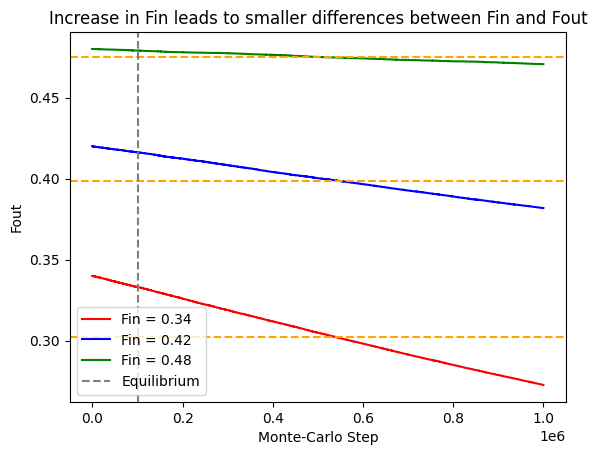

In [ ]:
#Simulation Plot for Fin and Fout
step_num = np.linspace(0,np.power(10,6),np.power(10,6))

plt.plot(step_num,fout_list_34,color = 'red', label='Fin = 0.34') #fin= 0.34

plt.plot(step_num,fout_list_42,color = 'blue', label='Fin = 0.42') #fin= 0.42

plt.plot(step_num,fout_list_48,color = 'green', label='Fin = 0.48') #fin= 0.48

plt.axhline(y=fout_ave_48,color = 'orange',linestyle='--') #fin= 0.48
plt.axhline(y=fout_ave_42,color = 'orange',linestyle='--') #fin= 0.42
plt.axhline(y=fout_ave_34,color = 'orange',linestyle='--') #fin= 0.34

plt.axvline(x=np.power(10,5),color = 'gray',label = 'Equilibrium',linestyle='--') #equilibrium point

plt.xlabel('Monte-Carlo Step')
plt.ylabel('Fout')
plt.legend()
plt.title('Increase in Fin leads to smaller differences between Fin and Fout')
plt.show()

In [ ]:
# #Test Case
# lattice = np.ones((5,5))
# #lattice[y,x]
# lattice[0,0] = -1.0
# lattice[1,0] = -1.0
# lattice[1,1] = -1.0
# lattice[4,0] = -1.0
# lattice[4,1] = -1.0
# lattice[2,2] = -1.0
# lattice[3,2] = -1.0
# lattice[3,3] = -1.0
# lattice[4,3] = -1.0
# lattice[1,4] = -1.0
# lattice[2,4] = -1.0
# print(lattice)

# vertical_cluster_lat1 = vertical_cluster(lattice,5)
# print(vertical_cluster_lat1)

# final_cluster_info = map_area_perimeter(lattice,vertical_cluster_lat1,5)
# print(final_cluster_info)

lattice_ice_water = mapping_ice(0.48, 1024)

vertical_cluster1 = vertical_cluster(lattice_ice_water,1024)
#for e,v in vertical_cluster.items(): #print out line by line because too long to show in a single line
  #print(f'column{e} has {v}')

final_cluster = map_area_perimeter(lattice_ice_water,vertical_cluster1,1024)
for e,v in final_cluster.items(): #print out line by line because too long to show in a single line
  print(f'cluster number {e} has area,perimeter {v}')

## On average it takes 1.5 to 2 hours to run, the number you will see on the screen when running indicates at what number the loop is on.
## The code will finish running when the printed number on the screen = n-1

Streaming output truncated to the last 5000 lines.
cluster number 75713 has area,perimeter (5, 12)
cluster number 75714 has area,perimeter (1, 4)
cluster number 75715 has area,perimeter (16, 26)
cluster number 75716 has area,perimeter (1, 4)
cluster number 75717 has area,perimeter (26, 40)
cluster number 75718 has area,perimeter (11, 16)
cluster number 75719 has area,perimeter (1, 4)
cluster number 75720 has area,perimeter (10, 18)
cluster number 75721 has area,perimeter (11, 24)
cluster number 75722 has area,perimeter (41, 76)
cluster number 75723 has area,perimeter (4, 10)
cluster number 75724 has area,perimeter (10, 18)
cluster number 75725 has area,perimeter (19, 26)
cluster number 75726 has area,perimeter (7, 14)
cluster number 75727 has area,perimeter (1, 4)
cluster number 75728 has area,perimeter (1, 4)
cluster number 75729 has area,perimeter (16, 14)
cluster number 75730 has area,perimeter (9, 16)
cluster number 75731 has area,perimeter (7, 16)
cluster number 75732 has area,per

D: 1.6640041920251898


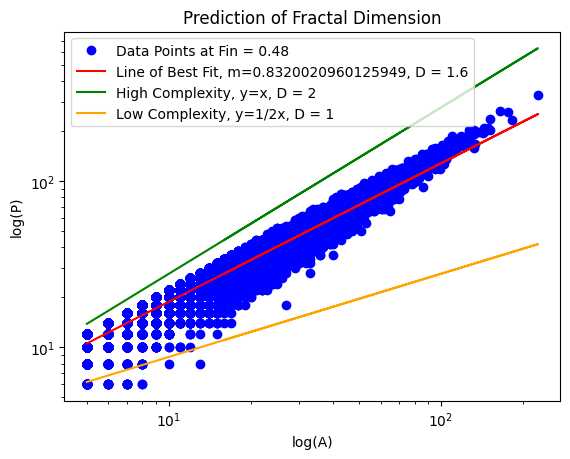

<Figure size 640x480 with 0 Axes>

In [ ]:
#Test Case Fractal Dimension Plot

A,P = find_peri_area(final_cluster) #A and P are filtered numpy array of area and perimeter respectively

log_A = np.log10(A)
log_P = np.log10(P)

m,b = np.polyfit(log_A,log_P,1)
print(f'D: {m*2}') # m = D/2

plt.loglog(A,P,'bo',label='Data Points at Fin = 0.48') #log log plot

plt.plot(A,10**(m*log_A+b),color = 'red', label=f'Line of Best Fit, m={m}, D = 1.6') #line of best fit

plt.plot(A,10**(1*log_A+b),color = 'green', label=f'High Complexity, y=x, D = 2')

plt.plot(A,10**((1/2)*log_A+b),color = 'orange', label=f'Low Complexity, y=1/2x, D = 1')

plt.xlabel('log(A)')
plt.ylabel('log(P)')
plt.legend()
plt.title('Prediction of Fractal Dimension')
plt.show()
plt.savefig('Prediction of Fractal Dimension Fin = 0_48.png',dpi =300)

In [ ]:
##Test Case Mapping Lattice

#Map Test case
# lattice_ice_water = mapping_ice(0.34, 1024)
# print(lattice_ice_water)

# counter = 0
# for j in range(1024):
#     for i in range(1024):
#       if lattice_ice_water[j,i] == -1.0:
#         counter += 1

# print(counter)

#Simulation Test case
# lattice_test_height = mapping_height(1024)
# lattice_test_water_ice = mapping_ice(0.34,1024)
# print(mc_lattice(lattice_test_water_ice,lattice_test_height)) #x = 1023, y = 1023 edge case pass
# print(mc_lattice(lattice_test_water_ice,lattice_test_height)) #x = 0, y = 0 edge case pass
# print(mc_lattice(lattice_test_water_ice,lattice_test_height)) #random cases worked
# Fout_list, Fout_ave = simulation(0.34,1024,6,5) #run during (~22s)
# simulation(1.2,1024,6,5) #expect Fin not float
# simulation(0.34,-3,6,5) #expect n is negative
# simulation(0.34,1024,5,5) #expect total < eq
# for fout in Fout_list[np.power(10,5)-1:]:
#   print(fout)

# print(f'Average Fout = {Fout_ave}')